# Zadanie

Zadaniem jest przeanalizowanie jednego ze zbiorów danych, dotyczących wynajmu lokali poprzez
platformę Airbnb (http://insideairbnb.com/get-the-data.html). Na warsztat wzięto zbiór, zawierający
dane szczegółowe (listings.csv.gz) dla miasta Nashville

In [1]:
import warnings
warnings.filterwarnings('ignore')

from nashville import Nashville as nv

# Klucz

## Zbiór danych Nashville Airbnb – wyjaśnienie najważniejszych kolumn  
*(listings.csv – najczęściej używane kolumny)*

| Kolumna                        | Typ       | Opis / znaczenie                                                                      | Najczęstsze zastosowanie / dlaczego ważna                  |
|--------------------------------|-----------|---------------------------------------------------------------------------------------|------------------------------------------------------------|
| `id`                           | integer   | Unikalny identyfikator ogłoszenia na Airbnb                                           | Główny klucz                                               |
| `name`                         | text      | Tytuł ogłoszenia                                                                      | Często zawiera wskazówki o stylu / lokalizacji             |
| `description`                  | text      | Pełny opis lokalu napisany przez gospodarza                                           | Długi tekst – przydatny przy NLP                           |
| `host_id`                      | integer   | Unikalny identyfikator gospodarza                                                     | Łączy ogłoszenia z konkretnym gospodarzem                  |
| `host_name`                    | text      | Imię (lub pseudonim) gospodarza                                                       | —                                                          |
| `host_since`                   | date      | Data założenia konta przez gospodarza                                                 | Wskazuje doświadczenie gospodarza                          |
| `host_is_superhost`            | boolean   | Czy gospodarz ma status Superhost? (t/f)                                              | **Bardzo silny wskaźnik jakości**                          |
| `host_listings_count`          | integer   | Łączna liczba aktywnych ogłoszeń tego gospodarza                                      | Pozwala wykryć profesjonalnych gospodarzy                  |
| `neighbourhood_cleansed`       | text      | Oczyszczona/oficjalna nazwa dzielnicy                                                 | **Najlepsza kolumna do grupowania według dzielnic**        |
| `latitude` / `longitude`       | float     | Współrzędne geograficzne (nieco przesunięte dla prywatności)                          | Mapowanie, obliczanie odległości                           |
| `property_type`                | text      | Rodzaj nieruchomości (Dom, Apartament, Loft, Tiny home…)                             | —                                                          |
| `room_type`                    | text      | Typ wynajmu: Entire home/apt • Private room • Shared room • Hotel room               | **Kluczowe do segmentacji cen**                            |
| `accommodates`                 | integer   | Maksymalna liczba gości, na jaką przygotowany jest lokal                              | Bardzo ważny czynnik cenowy                                |
| `bathrooms`                    | float     | Liczba łazienek (może być ułamkowa, np. 1.5)                                          | —                                                          |
| `bedrooms`                     | float     | Liczba sypialni                                                                       | Silny predyktor ceny                                       |
| `beds`                         | float     | Liczba łóżek                                                                          | —                                                          |
| `price`                        | string    | Cena za dobę (zazwyczaj w formacie "$150.00" – wymaga wyczyszczenia)                 | **Główna zmienna celu**                                    |
| `minimum_nights`               | integer   | Minimalna liczba nocy wymagana do rezerwacji                                          | Wpływa na typ gości (turyści vs długoterminowi)           |
| `availability_365`             | integer   | Liczba dni dostępności w ciągu najbliższych 365 dni (0–365)                          | Pokazuje realną aktywność obiektu                          |
| `number_of_reviews`            | integer   | Całkowita liczba recenzji                                                             | Wskaźnik popularności i aktywności                         |
| `review_scores_rating`         | float     | Ogólna ocena (najczęściej 0–100)                                                      | **Najważniejszy wskaźnik satysfakcji gości**               |
| `review_scores_cleanliness`    | float     | Ocena czystości (0–10)                                                                | Bardzo ważna dla percepcji gości                           |
| `review_scores_location`       | float     | Ocena lokalizacji (0–10)                                                              | Szczególnie ciekawa w Nashville                            |
| `instant_bookable`             | boolean   | Czy można rezerwować od razu (bez akceptacji gospodarza)? (t/f)                      | Wygoda rezerwacji                                          |
| `calculated_host_listings_count` | integer | Liczba ogłoszeń tego gospodarza w tej samej okolicy (według obliczeń Airbnb)        | **Najlepszy wskaźnik profesjonalnych gospodarzy**          |

### Najczęściej używane kolumny w analizach Nashville (2025/2026)

```text
price                        → cena za dobę (zmienna celu)
room_type                    → segmentacja (całe mieszkanie vs pokój prywatny)
neighbourhood_cleansed       → dzielnice
accommodates                 → liczba gości
host_is_superhost            → jakość / zaufanie
availability_365             → rzeczywista aktywność
review_scores_rating         → zadowolenie gości
calculated_host_listings_count → profesjonalny vs amatorski gospodarz

# Eksploracja

Eksploracja opiera się na przeglądaniu podstawowych wskaźników zmiennych
za pomocą interaktywnej tabeli, pozwalającej na przeszukiwanie oraz sortowanie

In [2]:
nv.raw.shape

(9443, 79)

In [3]:
nv.raw.sample(n=5).T

,3362,9260,2365,6212,100
id,54404678,1493604656583297192,46746874,1071779565910861985,4485271
listing_url,https://www.airbnb.com/rooms/54404678,https://www.airbnb.com/rooms/1493604656583297192,https://www.airbnb.com/rooms/46746874,https://www.airbnb.com/rooms/1071779565910861985,https://www.airbnb.com/rooms/4485271
scrape_id,20250923202825,20250923202825,20250923202825,20250923202825,20250923202825
last_scraped,2025-09-24,2025-09-24,2025-09-24,2025-09-24,2025-09-24
source,city scrape,city scrape,city scrape,city scrape,previous scrape
name,2 Townhomes w/Roof Decks + Grills,Hyve - Tropical Penthouse - Pool & Gym,12 South / Gulch Luxury Condo,New West End Stay | Rooftop Views,Sip Coffee by River & Stroll to Broadway’s Lig...
description,Discover your ultimate Nashville retreat! Two ...,"Welcome to Tropical Penthouse, your perfect ge...",Luxurious 2BR Downtown Condo – Sleeps 6<br />P...,Brand New Build! Three stories of refined fini...,The Location of this Condo is SIMPLY PERFECT!!...
neighborhood_overview,This property is located in the downtown area ...,SOBRO,"Walking distance to coffee, barkeries and eate...",90 WALK SCORE! Our home is located in the West...,The Condo is located right by the Cumberland R...
picture_url,https://a0.muscache.com/pictures/prohost-api/H...,https://a0.muscache.com/pictures/prohost-api/H...,https://a0.muscache.com/pictures/hosting/Hosti...,https://a0.muscache.com/pictures/prohost-api/H...,https://a0.muscache.com/pictures/miso/Hosting-...
host_id,373388104,531829128,101553583,335977682,23271865


In [2]:
nv.raw.itable(exclude_cols=['Most Common'])

Loading ITables v2.6.2 from the internet... (need help?)


# Wstępna transformacja

Obejmuje redukcje liczby (nierokujących) kolumn oraz konwersje typów wybranych zmiennych

## Redukcja kolumn

In [3]:
irrelevant = ['id', 'listing_url', 'scrape_id', 'source', 'name', 'host_id', 'host_name', 'host_about']
too_many_missing = ['calendar_updated', 'neighbourhood_group_cleansed', 'licence',
                    'neighborhood_overview', 'host_neighbourhood'
                   ]
image_related = ['host_thumbnail_url', 'picture_url', 
                 'host_has_profile_pic', 'host_picture_url', 'host_url'
                ]
other = ['description', 'neighbourhood', 
         'longitude', 'latitude', 
         'first_review', 'last_review', 
         'host_identity_verified',
         'host_location', 'review_scores_location', 
         'bathrooms_text', 
         'host_verifications', 'last_scraped', 'calendar_last_scraped',
         'host_response_rate', 'calculated_host_listings_count',
         'estimated_revenue_l365d', 'estimated_occupancy_l365d',
         'number_of_reviews_ly', 'availability_eoy',
         'calculated_host_listings_count_entire_homes',
         'calculated_host_listings_count_private_rooms',
         'calculated_host_listings_count_shared_rooms',
         'maximum_maximum_nights',
         'minimum_maximum_nights',
         'maximum_minimum_nights',
         'minimum_minimum_nights',
         'number_of_reviews_l30d',
         'number_of_reviews_ltm'
        
        ]

review_scores = ['reviews_per_month', 'review_scores_value', 'review_scores_communication', 
                 'review_scores_checkin', 'review_scores_cleanliness',
                 'review_scores_accuracy'
                ]
cols_to_drop = irrelevant + too_many_missing + image_related + review_scores + other

In [4]:
print('Dropping', len(cols_to_drop))
nv.transformer.drop_columns(*cols_to_drop)
nv.transformer.drop_rows(threshold=0.8)
def remove_rows_with_null_price(data):
    return data[~pd.isna(data.price)]

nv.transformer.apply(remove_rows_with_null_price)
nv.transformer.data.shape

Dropping 52


(6634, 27)

## Konwersja typów

In [5]:
import pandas as pd
import numpy as np

def bool2int(name, data):
    data[name] = data[name].map({'t': 1, 'f': 0})
    return data

def convert_price_to_float(data):
    data['price'] = data['price'].replace('[\\$,]', '', regex=True).astype(float)
    return data
    
def convert_superhost_to_int(data):
    return bool2int('host_is_superhost', data)

def convert_instant_bookable_to_int(data):
    return bool2int('instant_bookable', data)

def convert_has_availability_to_int(data):
    return bool2int('has_availability', data)
    
def convert_amenities_to_number(data):
    data['amenities'] = data['amenities'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
    return data

def convert_host_since_to_days(data):
    data['host_since'] = pd.to_datetime(data['host_since'], errors='coerce')
    today = pd.to_datetime('today')
    data['host_since'] = (today - data['host_since']).dt.days
    return data

def to_cat(name, data):
    data[name] = data[name].astype('category')
    return data

def convert_room_type_to_cat(data):
    return to_cat('room_type', data)


def convert_property_type(data):
    return to_cat('property_type', data)


def convert_host_response_time(data):
    return to_cat('host_response_time', data)


def convert_neighbourhood_cleansed(data):
    return to_cat('neighbourhood_cleansed', data)
    

def convert_acceptance_rate(data):
    col = "host_acceptance_rate"
    data[col] = (
    data[col]
    .astype(str)
    .str.rstrip("%")
    .replace("nan", np.nan)
    .astype(float)
    / 100.0
    )
    return data

    
nv.transformer.apply(
    convert_price_to_float,
    convert_superhost_to_int,
    convert_instant_bookable_to_int,
    convert_has_availability_to_int,
    convert_amenities_to_number,
    convert_host_since_to_days,
    convert_acceptance_rate,
    convert_room_type_to_cat,
    convert_property_type,
    convert_host_response_time,
    convert_neighbourhood_cleansed
    
)

# Analiza

Obejmuje wizualizację wybranych zmiennych w formie histogramów oraz wykresów pudełkowych

In [6]:
view = nv.transformer.data

## Dane kategorialne

In [7]:
exclude= ['Sample Values', 'Most Common', 'Is Numerical', 
          'Is Categorical', 'Min', 'Max', 'Median', 'Kurtosis', 'Skewness', 'Quartiles',
          'Std Dev', 'Mean'
         
         ]
view.itable(categorical_only= True, pivot=False, exclude_cols=exclude)

Loading ITables v2.6.2 from the internet... (need help?)


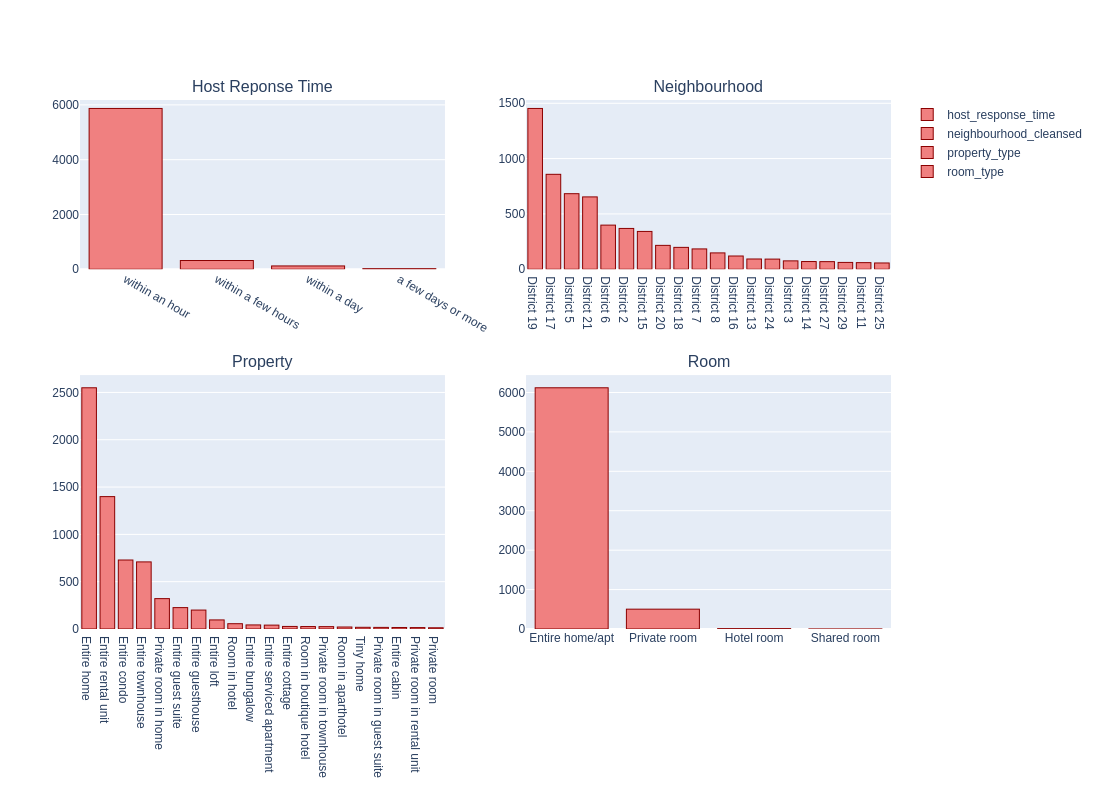

In [8]:

fig = view.make_subplots(2, 2, 
    subplot_titles=['Host Reponse Time', 'Neighbourhood', 'Property', 'Room'] ,
    row_heights=[0.02, 0.03],
    vertical_spacing=0.2
)

hrt = view.host_response_time.bar(show=False)
neigh = view.neighbourhood_cleansed.bar(show=False)
prop = view.property_type.bar(show=False)
room = view.room_type.bar(show=False)
fig.add_trace(hrt, row=1, col=1)
fig.add_trace(neigh, row=1, col=2)
fig.add_trace(prop, row=2, col=1)
fig.add_trace(room, row=2, col=2)
fig.update_layout(height=800)

## Dane numeryczne

In [9]:
view.itable(numerical_only= True, pivot=False, exclude_cols=['Most Common', 'Is Categorical', 'Is Numerical'])

Loading ITables v2.6.2 from the internet... (need help?)


### Histogram

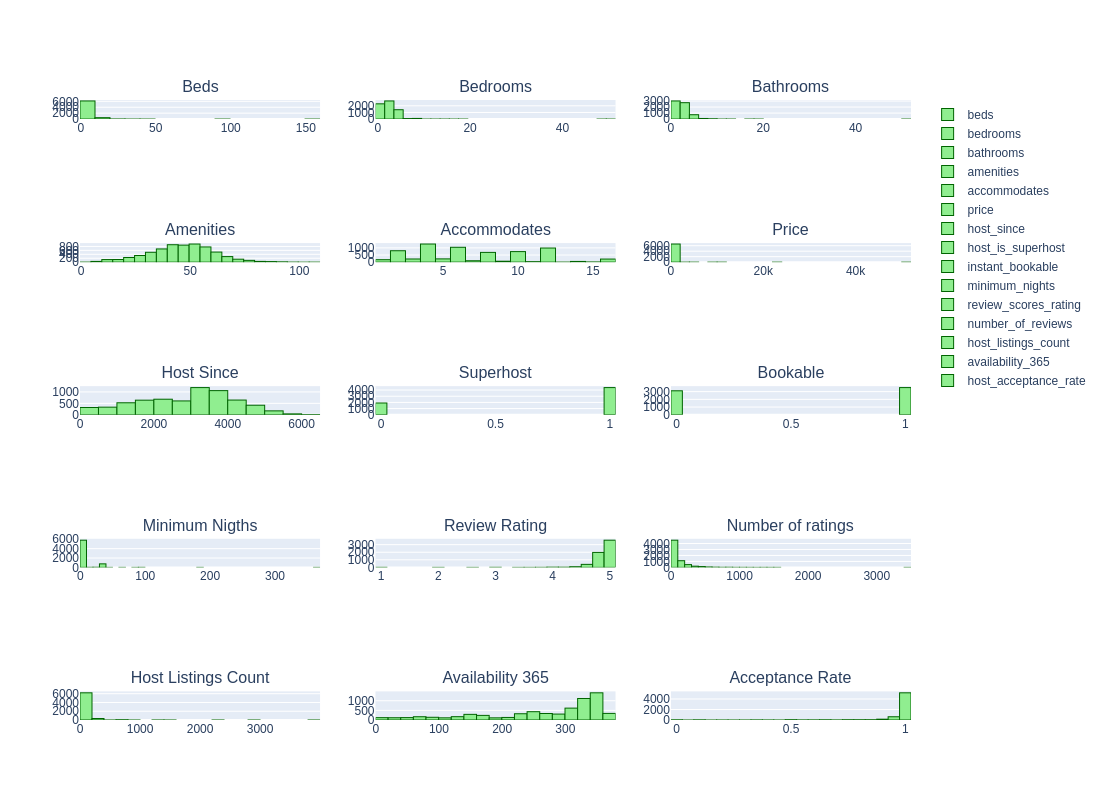

In [10]:

titles = ['Beds', 'Bedrooms', 'Bathrooms',
          'Amenities', 'Accommodates', 'Price',
          'Host Since', 'Superhost', 'Bookable',
          'Minimum Nigths', 'Review Rating', 'Number of ratings',
          'Host Listings Count', 'Availability 365', 'Acceptance Rate'
         ]
fig_n = view.make_subplots(5, 3, 
    subplot_titles=titles,
    row_heights=[0.02, 0.02, 0.03, 0.03, 0.03],
    vertical_spacing=0.2)

beds = view.beds.hist(show=False), (1, 1)
bedr = view.bedrooms.hist(show=False), (1, 2)
bath = view.bathrooms.hist(show=False), (1, 3)
amm = view.amenities.hist(show=False), (2, 1)
acc = view.accommodates.hist(show=False), (2, 2)
prc = view.price.hist(show=False), (2, 3)
hs = view.host_since.hist(show=False), (3, 1)
sup = view.host_is_superhost.hist(show=False), (3, 2)
book = view.instant_bookable.hist(show=False), (3, 3)
mn = view.minimum_nights.hist(show=False, bins=50), (4, 1)
rr = view.review_scores_rating.hist(show=False), (4, 2)
nr = view.number_of_reviews.hist(show=False, bins=50), (4, 3)
hlc = view.host_listings_count.hist(show=False), (5, 1)
av = view.availability_365.hist(show=False), (5, 2)
ar = view.host_acceptance_rate.hist(show=False), (5, 3)

histograms = [beds, bedr, bath, amm, acc, prc, hs, sup ,book, mn, rr, nr, hlc, av, ar]
for trace, pos in histograms:
    fig_n.add_trace(trace, *pos)
fig_n.update_layout(height=800)
fig_n


### Boxplot

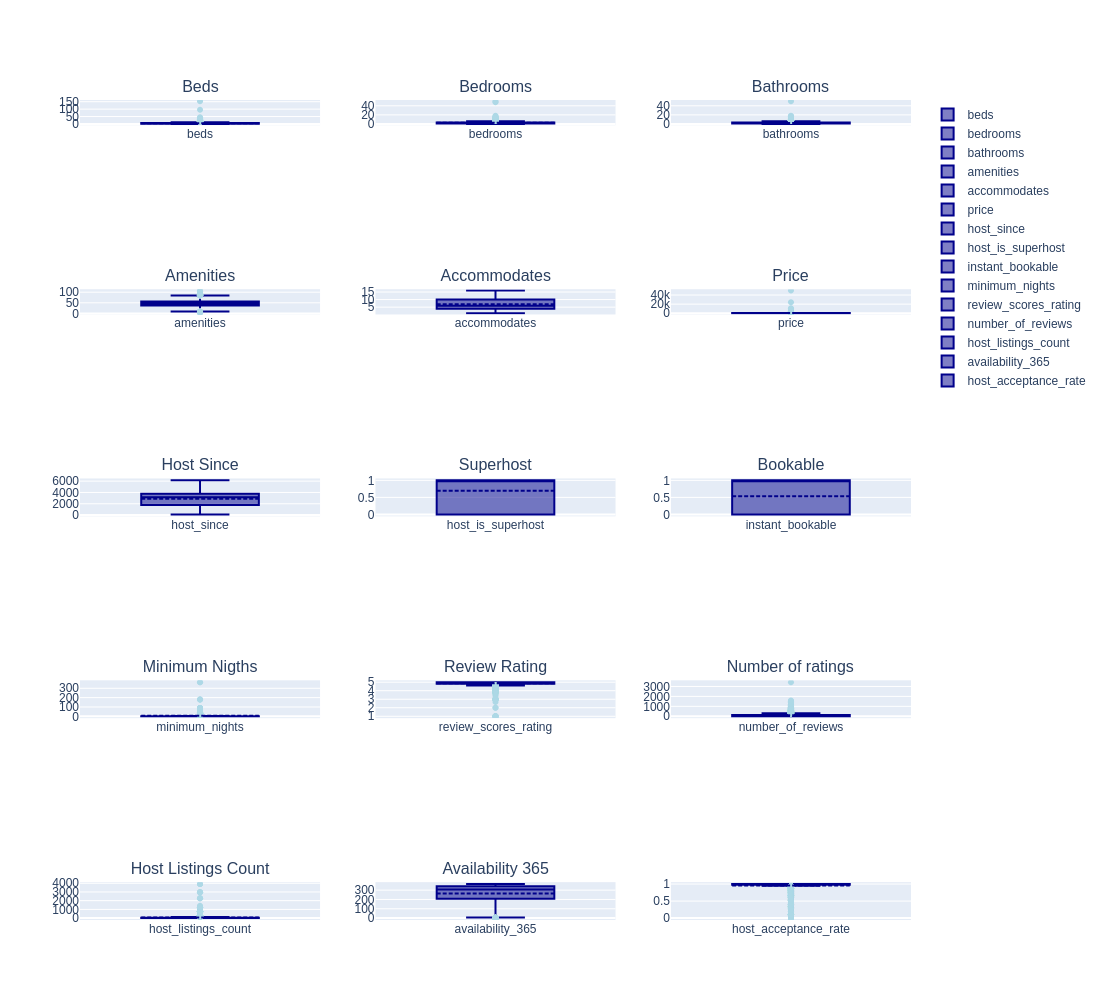

In [11]:
titles = ['Beds', 'Bedrooms', 'Bathrooms',
          'Amenities', 'Accommodates', 'Price',
          'Host Since', 'Superhost', 'Bookable',
          'Minimum Nigths', 'Review Rating', 'Number of ratings',
          'Host Listings Count', 'Availability 365'
         ]
fig_box = view.make_subplots(5, 3, 
    subplot_titles=titles,
    row_heights=[0.02, 0.02, 0.03, 0.03, 0.03],
    vertical_spacing=0.2)

beds = view.beds.box(show=False), (1, 1)
bedr = view.bedrooms.box(show=False), (1, 2)
bath = view.bathrooms.box(show=False), (1, 3)
amm = view.amenities.box(show=False), (2, 1)
acc = view.accommodates.box(show=False), (2, 2)
prc = view.price.box(show=False), (2, 3)
hs = view.host_since.box(show=False), (3, 1)
sup = view.host_is_superhost.box(show=False), (3, 2)
book = view.instant_bookable.box(show=False), (3, 3)
mn = view.minimum_nights.box(show=False), (4, 1)
rr = view.review_scores_rating.box(show=False), (4, 2)
nr = view.number_of_reviews.box(show=False), (4, 3)
hlc = view.host_listings_count.box(show=False), (5, 1)
av = view.availability_365.box(show=False), (5, 2)
ar = view.host_acceptance_rate.box(show=False), (5, 3)

boxplots = [beds, bedr, bath, amm, acc, prc, hs, sup ,book, mn, rr, nr, hlc, av, ar]
for trace, pos in boxplots:
    fig_box.add_trace(trace, *pos)
fig_box.update_layout(height=1000)
fig_box


# Czyszczenie

## Uzupełnianie braków

In [12]:
items = [item for item in view.list_by_null_ratio(descending=True) if item.missing_values > 0]
for item in items:
    print(item.name, item.missing_values, item.dtype, item.sample_values)

review_scores_rating 501 float64 [4.95, 4.93, 4.92, 4.78, 4.71]
host_is_superhost 336 float64 [0.0, 1.0]
host_response_time 300 category ['within a day', 'within an hour', 'within a few hours', 'a few days or more']
host_acceptance_rate 228 float64 [0.91, 0.96, 1.0, 0.97, 0.56]
has_availability 30 float64 [1.0, 0.0]
bedrooms 9 float64 [1.0, 2.0, 0.0, 4.0, 3.0]
host_since 3 float64 [6133.0, 5662.0, 5659.0, 6056.0, 5099.0]
host_listings_count 3 float64 [1.0, 18.0, 5.0, 2.0, 3.0]
host_total_listings_count 3 float64 [1.0, 2.0, 25.0, 7.0, 4.0]
bathrooms 1 float64 [1.0, 2.5, 1.5, 2.0, 3.0]
beds 1 float64 [1.0, 2.0, 3.0, 4.0, 6.0]


In [13]:
for col in ['beds', 'bathrooms', 'bedrooms', 'host_listings_count', 'host_total_listings_count', 'host_since']:
    nv.transformer.fill_missing(col, strategy='median')
nv.transformer.fill_missing('has_availability', strategy='constant', value=0)
nv.transformer.fill_missing('review_scores_rating', strategy='mean')
nv.transformer.fill_missing('host_acceptance_rate', strategy='mean')

In [14]:
def fill_host_is_superhost(data):
    mask = data["host_is_superhost"].isnull()
    data.loc[mask, "host_is_superhost"] = data.loc[mask, "number_of_reviews"].apply(lambda x: 1 if x > 1000 else 0)
    return data
nv.transformer.apply(fill_host_is_superhost)

## Normalizacja danych numerycznych wg skośności

In [15]:
nv.transformer.data.itable(numerical_only=True, exclude_cols=[
    'Most Common', 'Sample Values', 'Data Type', 

    'Min', 'Max', 'Median', 'Std Dev', 'Quartiles', 'Null Ratio',
    'Is Categorical', 'Is Numerical', 'Missing Values', 'Total Count', 'Unique Values'

])

Loading ITables v2.6.2 from the internet... (need help?)


In [17]:
nv.transformer.apply_log_transform('price')
nv.transformer.apply_log_transform('review_scores_rating')
nv.transformer.apply_log_transform('host_listings_count')


## Kodowanie danych kategorialnych

Konwersja wartości kategorialnych do odpowiadającego im kodu jako integer

In [18]:
nv.transformer.label_encode('property_type')
nv.transformer.label_encode('room_type')
nv.transformer.label_encode('neighbourhood_cleansed')
nv.transformer.label_encode('host_response_time')

In [19]:
nv.transformer.data.itable()

Loading ITables v2.6.2 from the internet... (need help?)


# Badanie zależności

## Macierz korelacji

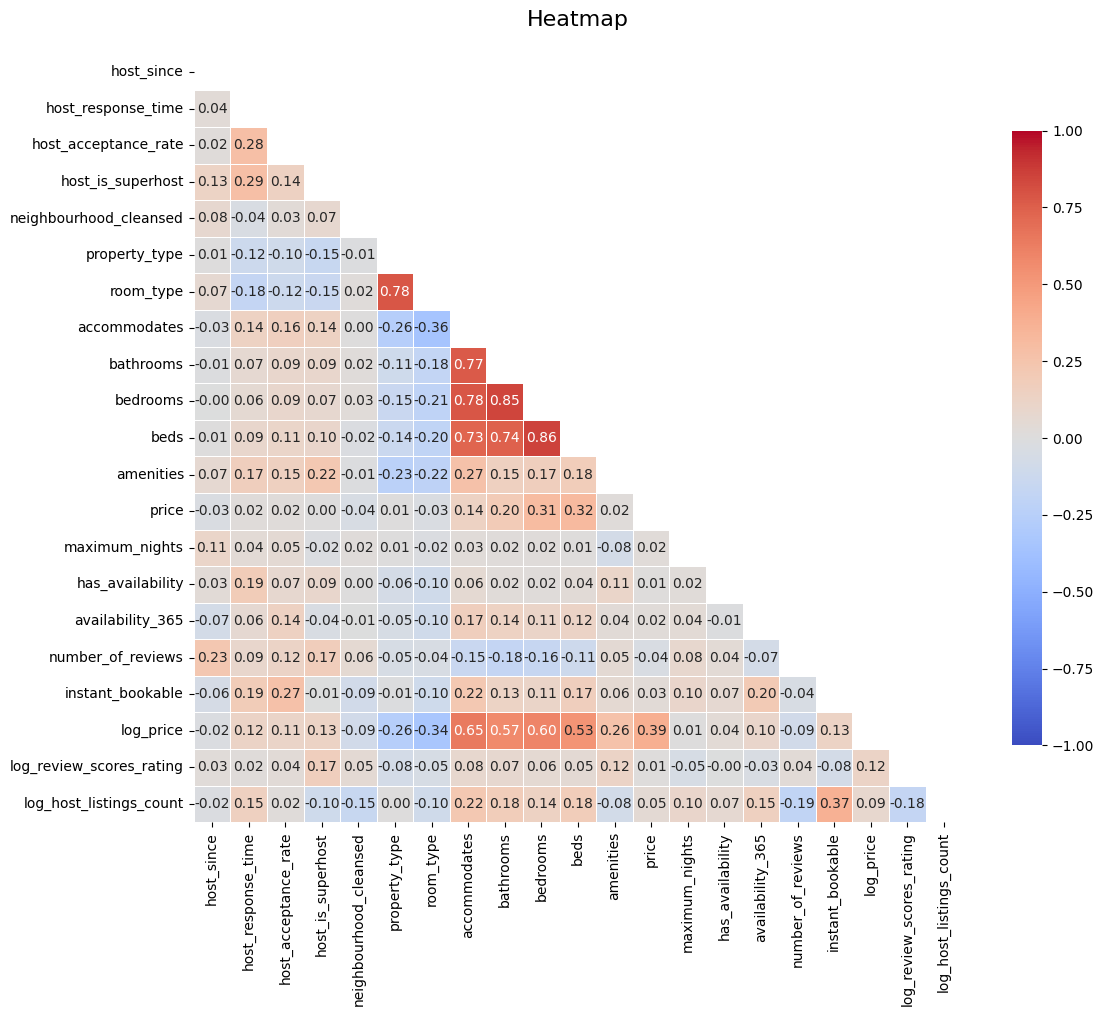

In [38]:
exclude = ['host_total_listings_count', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
           'availability_30', 'availability_60',
           'availability_90',
           'minimum_nights', 'review_scores_rating', 'host_listings_count'
          ]
nv.transformer.data.heatmap(exclude_cols=exclude)

## Rozrzut

In [21]:
data = nv.transformer.data

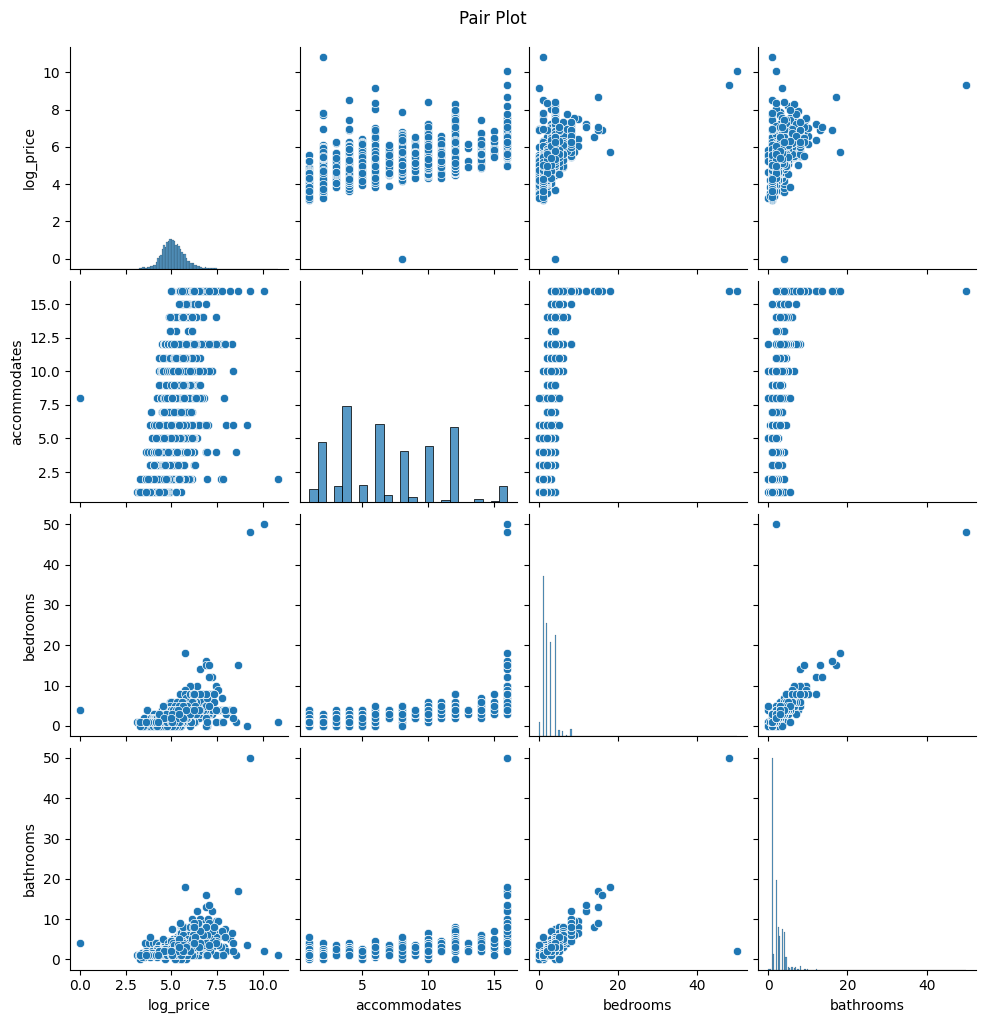

In [29]:
data.pair_plot(include_cols=['log_price', 'accommodates', 'bedrooms', 'bathrooms'])

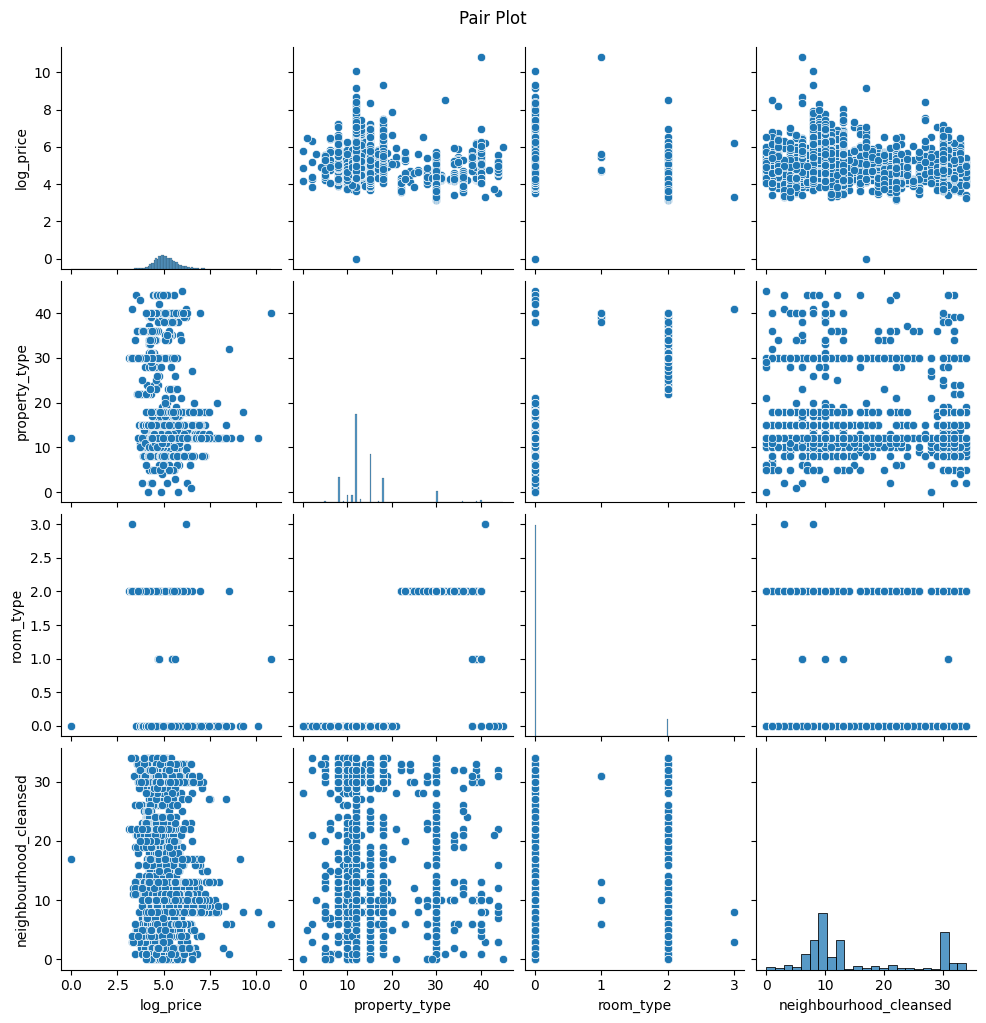

In [23]:
data.pair_plot(include_cols=['log_price', 'property_type', 'room_type', 'neighbourhood_cleansed'])

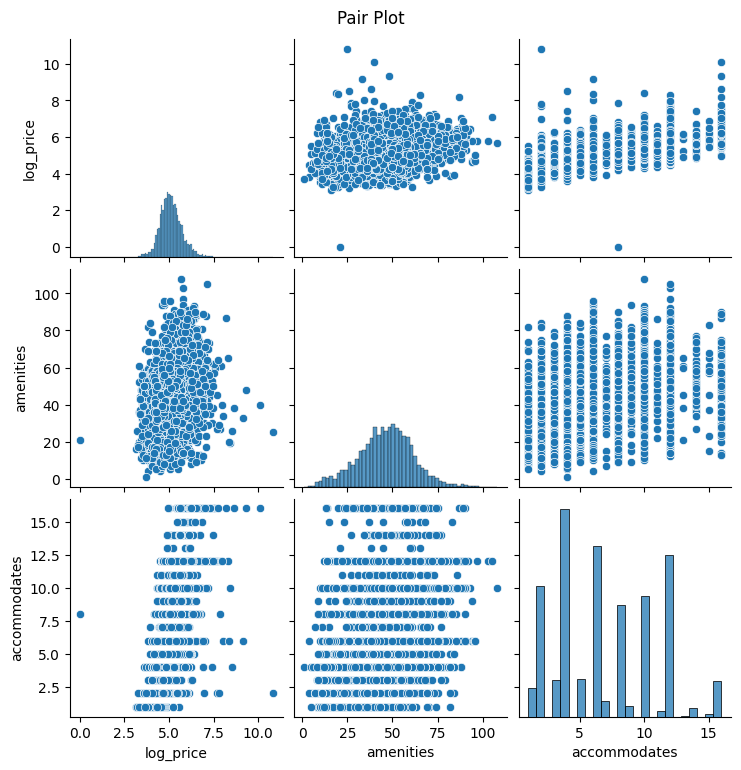

In [25]:
data.pair_plot(include_cols=['log_price', 'amenities', 'accommodates'])

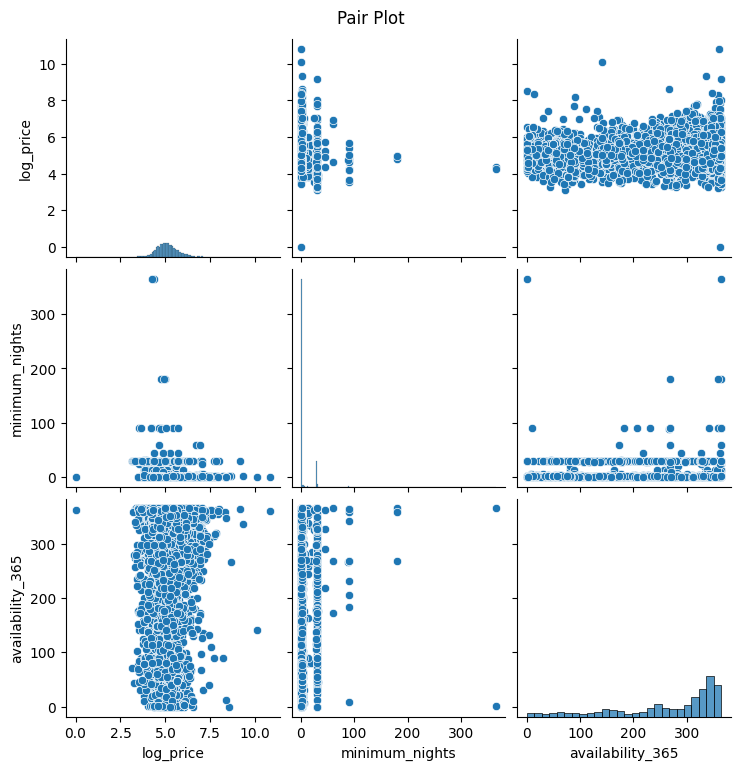

In [27]:
data.pair_plot(include_cols=['log_price', 'minimum_nights', 'availability_365'])